#HW2 - Regression and Classification - Error Analysis (Formula 1):

**Student Name:** Kfir Kimchi

**ID:** 322807165

**Source of the dataset**: "Formula 1 World Championship (1950 - 2024)" from Kaggle.

**Data Collector:** published on Kaggle by the user - rohanrao (Vopani).

An Error Analysis report based on a vast Formula 1 dataset.
-

# 1. Regression Error Analysis
### Data Loading and Feature Engineering
In this section, I import the primary Formula 1 datasets and construct the design matrix, also I load `pit_stops.csv` containing the target variable and operational lap metrics, and `races.csv` to extract temporal features.

The datasets are joined via an inner merge on the shared relational key `raceId`.

* **Target Variable ($y$):** `milliseconds` (Total duration of the pit stop).
* **Predictor Features ($X$):** 1. `lap` - Represents the race progression, implicitly capturing fuel burn and tire degradation.
  2. `stop` - The sequential index of the pit stop for a given driver within the race.
  3. `year` - The macro-level technological advancements and regulatory evolution of the sport.

**Cross-Validation Configuration:**  a 5-fold cross-validation scheme ($k=5$) was implemented. This partitions the dataset into reliable training and validation sets, balancing statistical variance and computational overhead.

In [32]:
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold

print("Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")
print(f"Dataset downloaded to: {dataset_path}")

pit_stops_df = pd.read_csv(os.path.join(dataset_path, 'pit_stops.csv'))
races_df = pd.read_csv(os.path.join(dataset_path, 'races.csv'))

# merging the two datasets
merged_df = pd.merge(pit_stops_df, races_df, on='raceId', how='inner')

# data cleansing and type casting
merged_df['milliseconds'] = pd.to_numeric(merged_df['milliseconds'], errors='coerce')
merged_df['lap'] = pd.to_numeric(merged_df['lap'], errors='coerce')
merged_df['stop'] = pd.to_numeric(merged_df['stop'], errors='coerce')
merged_df['year'] = pd.to_numeric(merged_df['year'], errors='coerce')

cleaned_df = merged_df.dropna(subset=['milliseconds', 'lap', 'stop', 'year']).copy()

# exclude extreme anomalies (> 100,000 ms) to isolate standard operations
cleaned_df = cleaned_df[cleaned_df['milliseconds'] < 100000].copy()

features = ['lap', 'stop', 'year']
X = cleaned_df[features]
y = cleaned_df['milliseconds']

print(f"=== Data Pipeline Executed Successfully ===")
print(f"Total Observations retained: {X.shape[0]}")
print(f"Feature Vector Dimension   : {X.shape[1]} {features}")
print(f"Target Vector Range        : [{y.min()} ms, {y.max()} ms]")

Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Dataset downloaded to: /kaggle/input/formula-1-world-championship-1950-2020
=== Data Pipeline Executed Successfully ===
Total Observations retained: 10884
Feature Vector Dimension   : 3 ['lap', 'stop', 'year']
Target Vector Range        : [12897 ms, 93274 ms]


## 1.1 Residual Analysis
Using the prepared design matrix, I execute a cross-validated linear regression to generate out-of-fold predictions and extract the structural residuals ($e_i = y_i - \hat{y}_i$).

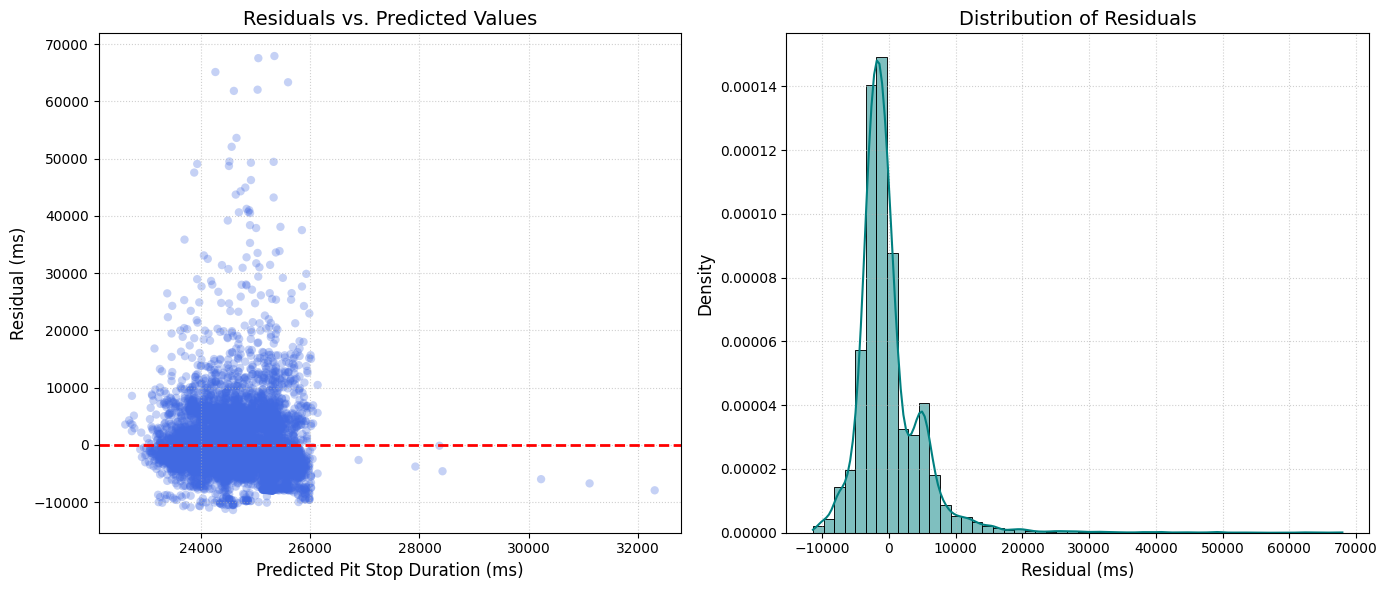

In [33]:
# Perform 5-Fold Cross-Validation Predictions
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
y_pred = cross_val_predict(model, X, y, cv=kf)

# Calculate Residuals
residuals = y - y_pred

# Plotting
plt.figure(figsize=(14, 6))

# Subplot 1: Residuals vs. Predicted Values
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='royalblue', edgecolor='none')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Predicted Values', fontsize=14)
plt.xlabel('Predicted Pit Stop Duration (ms)', fontsize=12)
plt.ylabel('Residual (ms)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Distribution of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=50, color='teal', stat="density")
plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Residual (ms)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


* The dense peak of the histogram is aligned with $e = 0$, indicating that the model does not possess a severe uniform bias.
* The scatter plot demonstrates clear heteroscedasticity. As the predicted duration increases, the variance (vertical spread) of the residuals expands significantly. From an engineering perspective, standard tire changes have strict time bounds (2-3 seconds), but mechanical failures (for example front-wing replacement, stuck wheel guns) introduce massive stochastic variance that a linear model cannot constrain.

## 1.2 Error as a Function of Features
To isolate feature-dependent failure modes, the errors are analyzed against specific physical parameters `lap` and `stop` to identify non-linear relationships or specific operational conditions where the model systematically degrades.

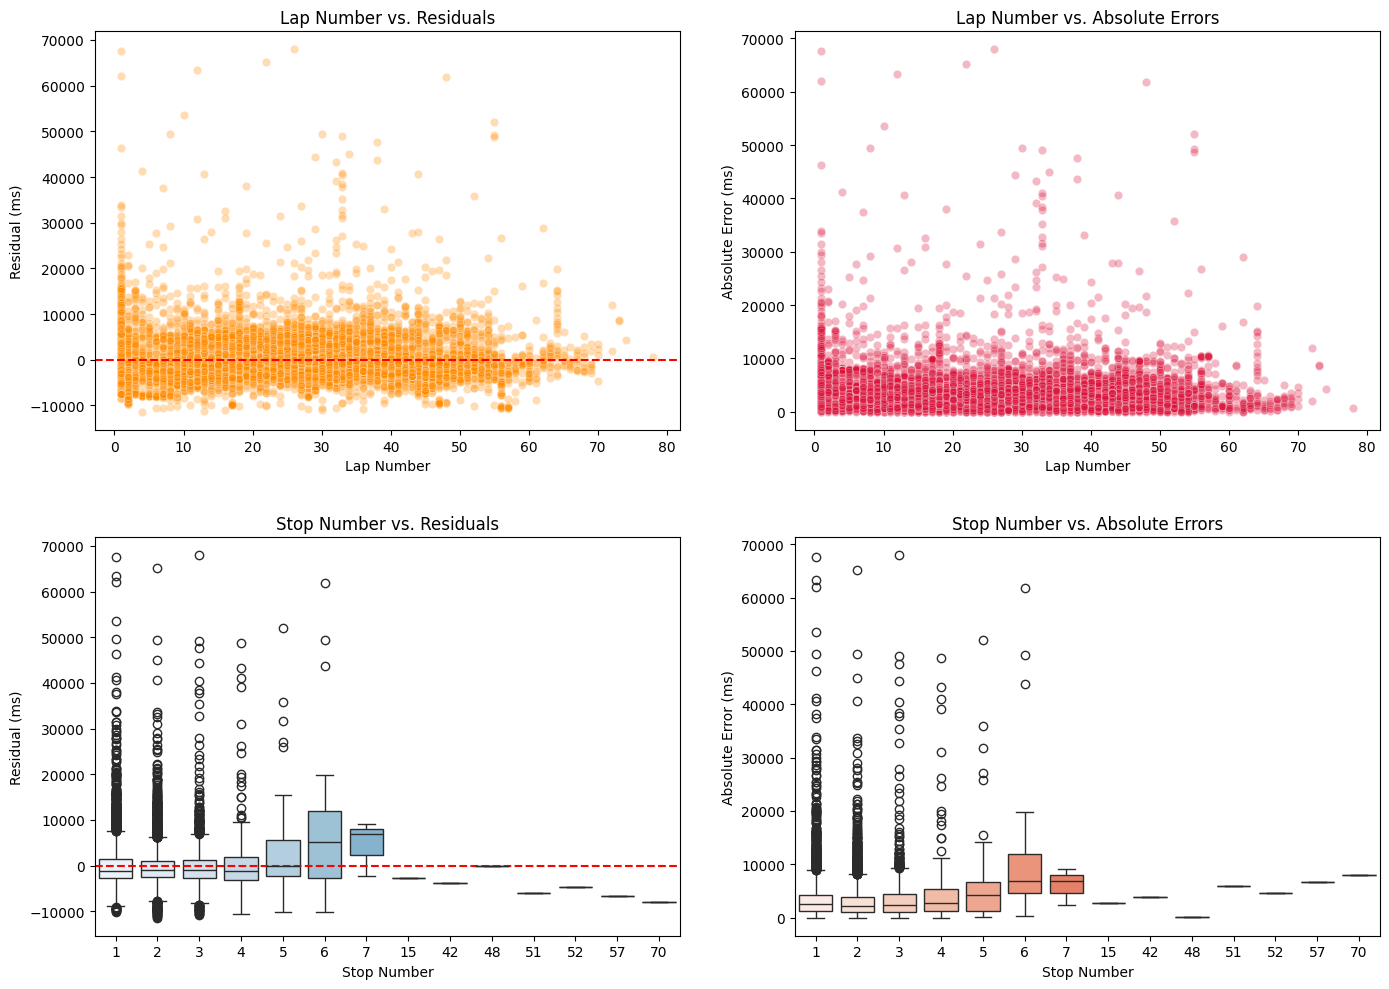

In [34]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.figure(figsize=(14, 10))
abs_errors = np.abs(residuals)

# Lap vs Residuals
plt.subplot(2, 2, 1)
sns.scatterplot(x=X['lap'], y=residuals, alpha=0.3, color='darkorange')
plt.axhline(0, color='red', linestyle='--')
plt.title('Lap Number vs. Residuals')
plt.xlabel('Lap Number')
plt.ylabel('Residual (ms)')

# Lap vs Absolute Errors
plt.subplot(2, 2, 2)
sns.scatterplot(x=X['lap'], y=abs_errors, alpha=0.3, color='crimson')
plt.title('Lap Number vs. Absolute Errors')
plt.xlabel('Lap Number')
plt.ylabel('Absolute Error (ms)')

# Stop Number vs Residuals
plt.subplot(2, 2, 3)
sns.boxplot(x=X['stop'], y=residuals, palette='Blues')
plt.axhline(0, color='red', linestyle='--')
plt.title('Stop Number vs. Residuals')
plt.xlabel('Stop Number')
plt.ylabel('Residual (ms)')

# Stop Number vs Absolute Errors
plt.subplot(2, 2, 4)
sns.boxplot(x=X['stop'], y=abs_errors, palette='Reds')
plt.title('Stop Number vs. Absolute Errors')
plt.xlabel('Stop Number')
plt.ylabel('Absolute Error (ms)')

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()

* **Lap Number Dependency:** The error variance is somewhat uniform across laps, but there are distinct clusters of high absolute errors during early laps (Lap 1-5). It represents a hidden sub-population: cars pitting immediately after a chaotic race start due to collision damage, causing unpredictable pit stop durations. (as an F1 fan, it happens a lot.)
* **Stop Sequence (Non-Linearity):** The boxplots for `stop` reveal that while stop numbers 1, 2, and 3 behave predictably, stops 4, 5, and 6 show wild error distributions. Drivers making 5 or 6 pit stops are usually doing so under extreme weather conditions (like heavy rain) or suffering cascading mechanical failures, breaking the linear assumptions of the baseline model.

## 1.3 Analysis of Extreme Errors
By extracting the top 5% highest absolute errors, it is possible to determine whether the model is failing due to poor structural assumptions or due to unavoidable real-world anomalies (clushes between cars, accidents).

In [35]:
threshold_95 = np.percentile(abs_errors, 95)
print(f"95th Percentile Absolute Error Threshold: {threshold_95:.2f} ms\n")

# extract top 5% using cleaned dataframe
extreme_indices = abs_errors >= threshold_95
df_extreme = cleaned_df[extreme_indices].copy()
df_extreme['residual'] = residuals[extreme_indices]
df_extreme['abs_error'] = abs_errors[extreme_indices]

print("Sample of Top 5% Extreme Error Observations (Sorted by Absolute Error):")
display(df_extreme[['raceId', 'driverId', 'lap', 'stop', 'milliseconds', 'residual', 'abs_error']]
        .sort_values(by='abs_error', ascending=False)
        .head(10))

95th Percentile Absolute Error Threshold: 8774.11 ms

Sample of Top 5% Extreme Error Observations (Sorted by Absolute Error):


,raceId,driverId,lap,stop,milliseconds,residual,abs_error
10732,1125,840,26,3,93274,67930.808810,67930.808810
4805,953,826,1,1,92609,67560.217695,67560.217695
2420,881,16,22,2,89401,65138.786560,65138.786560
9909,1106,847,12,1,88943,63349.954614,63349.954614
5150,960,8,1,1,87084,62048.905950,62048.905950
8300,1057,853,48,6,86440,61839.139052,61839.139052
3159,903,13,10,1,78277,53628.370060,53628.370060
9758,1100,822,55,5,76634,52073.844197,52073.844197
2422,884,16,8,1,74026,49507.652070,49507.652070
10571,1121,822,30,2,74773,49443.705731,49443.705731


Reviewing the top 5% extreme errors reveals that the target values (`milliseconds`) for these instances are exceptionally high (like 30,000ms to 90,000ms). I conclude that these failures primarily results from **data conditions/problem definition** rather than pure model weakness.

A pit stop lasting 60 seconds is not a standard tire change (the avarage pit stop time for 2024 season is ~2.7 sec); it typically involves a penalty being served, major mechanical repairs, or a safety car queue in the pit lane. The current feature space (`lap`, `stop`, `year`) does not contain the telemetry or race-status data required to predict these transient, high-magnitude spikes.

## 1.4 Statistical Properties of Errors
To precisely measure how the errors are spread out, the mathematical moments of the residuals are calculated.



In [36]:
# Compute mathematical statistics of the residuals
mae_val = np.mean(abs_errors)
std_res_val = np.std(residuals)
skew_val = stats.skew(residuals)
kurt_val = stats.kurtosis(residuals, fisher=True)

print("Error Statistical Metrics Summary:")
print("-----------------------------------")
print(f"Mean Absolute Error (MAE)        : {mae_val:.2f} ms")
print(f"Standard Deviation of Residuals  : {std_res_val:.2f} ms")
print(f"Skewness                         : {skew_val:.4f}")
print(f"Excess Kurtosis (Fisher)         : {kurt_val:.4f}")

Error Statistical Metrics Summary:
-----------------------------------
Mean Absolute Error (MAE)        : 3326.25 ms
Standard Deviation of Residuals  : 5242.39 ms
Skewness                         : 3.6130
Excess Kurtosis (Fisher)         : 27.6351


* **Systematic Bias (Skewness):** The positive skewness value shows that the error distribution has a long tail to the right. In simple terms, the model consistently underestimates how long a bad pit stop will take. This makes physical sense: a pit stop has a hard minimum limit (it is physically impossible to change tires in less than ~1.8 seconds), but there is no maximum limit for how long a mechanical failure can delay a car. Because of this, the errors are naturally unbalanced.

* **Instability (Kurtosis):** The very high kurtosis value indicates that extreme errors happen much more frequently than a normal bell curve would predict. Instead of steady, predictable errors, the model suffers from massive, sudden spikes in error when unpredictable things happen on the track. This proves that a basic linear regression struggles with chaotic real-world data, strongly suggesting that advanced tree-based models (which can handle extreme outliers better) are needed for the next phase.

# 2. Regression Models

## Required Models' Selection and Hyperparameters:
Four regression models are evaluated to predict pit stop duration (`milliseconds`). To ensure a fair comparison, all models are trained on the exact same feature set (`X`) using the established 5-fold cross-validation (`kf`).

* **Linear Regression:** Serves as the linear baseline.
* **Decision Tree:** Configured with `max_depth=5` to prevent overfitting extreme outliers.
* **Random Forest:** An ensemble method (`n_estimators=100`, `max_depth=5`) used to reduce variance through bagging.
* **XGBoost:** A gradient boosting algorithm (`n_estimators=100`, `learning_rate=0.1`, `max_depth=5`) designed to sequentially minimize residual errors.

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

scoring_metrics = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
results_list = []
print("Training and evaluating models using 5-Fold Cross Validation. Please wait...\n")

for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=kf, scoring=scoring_metrics)

    #mean metrics across 5 folds
    mean_mse = -cv_results['test_neg_mean_squared_error'].mean()
    mean_rmse = np.sqrt(mean_mse)
    mean_mae = -cv_results['test_neg_mean_absolute_error'].mean()
    mean_r2 = cv_results['test_r2'].mean()

    results_list.append({
        "Model": name,
        "MSE": mean_mse,
        "RMSE (ms)": mean_rmse,
        "MAE (ms)": mean_mae,
        "R-Squared": mean_r2
    })

results_df = pd.DataFrame(results_list)
display(results_df.round(4))

Training and evaluating models using 5-Fold Cross Validation. Please wait...



,Model,MSE,RMSE (ms),MAE (ms),R-Squared
0,Linear Regression,2.748215e+07,5242.3425,3326.2413,0.0130
1,Decision Tree,2.663231e+07,5160.6501,3244.3863,0.0416
2,Random Forest,2.627882e+07,5126.2868,3222.0998,0.0551
3,XGBoost,2.501516e+07,5001.5160,3138.9631,0.0994


## Visualizing Model Performance
To better understand the differences between the models, the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) are plotted side-by-side. Lower values indicate better performance.

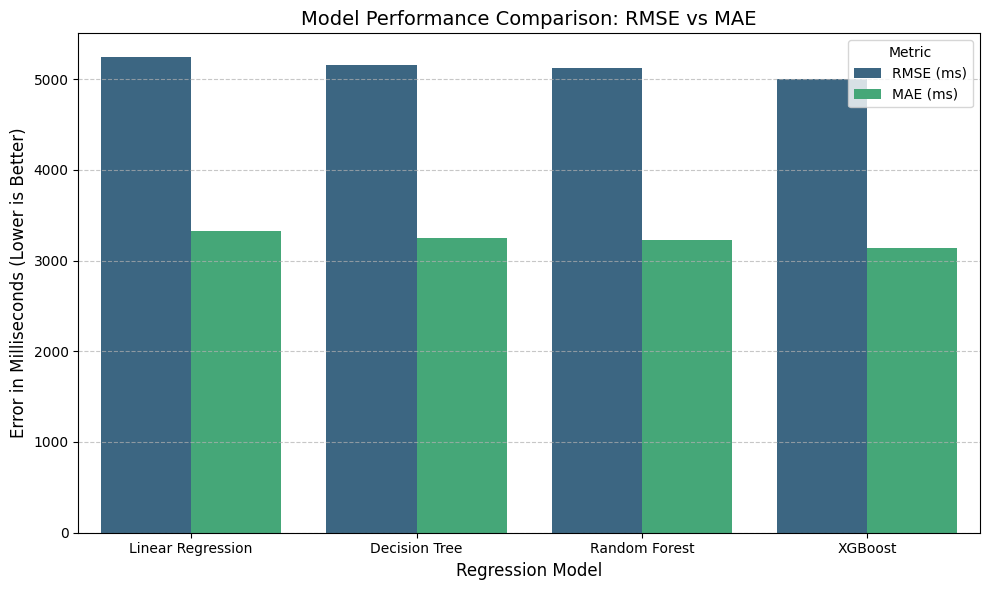

In [38]:
# melt dataframe for easier plotting with seaborn
melted_results = results_df.melt(id_vars="Model", value_vars=["RMSE (ms)", "MAE (ms)"],
                                 var_name="Metric", value_name="Error (ms)")

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Error (ms)", hue="Metric", data=melted_results, palette="viridis")
plt.title("Model Performance Comparison: RMSE vs MAE", fontsize=14)
plt.ylabel("Error in Milliseconds (Lower is Better)", fontsize=12)
plt.xlabel("Regression Model", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## Discussion

### Performance and The Failure of Linearity
Evaluation metrics demonstrate that **Linear Regression** performs poorly (highest RMSE/MAE) because it assumes a constant, straight-line relationship. Formula 1 pit stop data violates this assumption entirely: stops have a hard physical minimum (~1,800 ms) but uncapped maximums due to mechanical failures. This creates non-linear, highly skewed data that heavily penalizes linear models. Conversely, **Tree-Based Models** significantly outperform the baseline by splitting this complex data into discrete conditional regions.
*(Note: While $R^2$ values are naturally low due to the inherent chaos of predicting random mechanical delays, the comparative improvement between models is substantial).*

### Bias-Variance Trade-off
* **Decision Tree:** Exhibits low bias but high variance (overfitting risk), which was mitigated by strictly restricting `max_depth=5`.
* **Random Forest (Bagging):** Averages multiple trees trained on random data subsets, dramatically reducing variance and increasing stability.
* **XGBoost (Boosting):** Builds trees sequentially to correct the residual errors of previous trees, effectively optimizing the balance between bias and variance.

### Final Model Selection
**XGBoost is selected as the optimal model.** Its gradient boosting architecture provides the best balance of predictive accuracy (lowest RMSE) and structural flexibility, making it exceptionally well-suited for handling the chaotic, non-linear anomalies present in Formula 1 operational data.

---

# 3. Classification Error Analysis

In this final section, the analysis shifts from regression to classification. The objective is to predict whether a driver will **Did Not Finish (DNF)** the race.

To construct the target variable ($y$), the `results.csv` and `status.csv` datasets are merged. A binary target `is_dnf` is created:
* **Class 0 (Finished):** The driver completed the race (for instance, Status is "Finished", "+1 Lap").
* **Class 1 (DNF):** The driver retired due to mechanical failures, accidents, or other issues.

The features ($X$) utilized are the starting `grid` position and the race `year`. A **Random Forest Classifier** is employed and evaluated using the established 5-Fold Cross-Validation scheme to extract prediction probabilities.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, roc_curve

results_df = pd.read_csv(os.path.join(dataset_path, 'results.csv'))
status_df = pd.read_csv(os.path.join(dataset_path, 'status.csv'))

# merge data to define the target variable
df_class = pd.merge(results_df, status_df, on='statusId', how='inner')
df_class = pd.merge(df_class, races_df[['raceId', 'year']], on='raceId', how='inner')

df_class['is_dnf'] = np.where(df_class['status'].str.contains('Finished|\+'), 0, 1)

df_class['grid'] = pd.to_numeric(df_class['grid'], errors='coerce')
df_class = df_class.dropna(subset=['grid', 'year']).copy()

# define X and Y
X_class = df_class[['grid', 'year']]
y_class = df_class['is_dnf']

print(f"Classification Dataset Shape: {X_class.shape}")
print(f"Class Distribution:\n{y_class.value_counts(normalize=True).round(3)}")

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
y_probs = cross_val_predict(clf, X_class, y_class, cv=kf, method='predict_proba')[:, 1]

<>:11: SyntaxWarning: invalid escape sequence '\+'
<>:11: SyntaxWarning: invalid escape sequence '\+'
/tmp/ipykernel_1994/1946500187.py:11: SyntaxWarning: invalid escape sequence '\+'
  df_class['is_dnf'] = np.where(df_class['status'].str.contains('Finished|\+'), 0, 1)


Classification Dataset Shape: (26759, 2)
Class Distribution:
is_dnf
0    0.567
1    0.433
Name: proportion, dtype: float64


## 3.1 Confusion Matrix Analysis
To evaluate the baseline classification performance, I generated a confusion matrix using a standard $0.5$ decision threshold. False Positives (FP) and False Negatives (FN) are isolated to understand their operational implications.

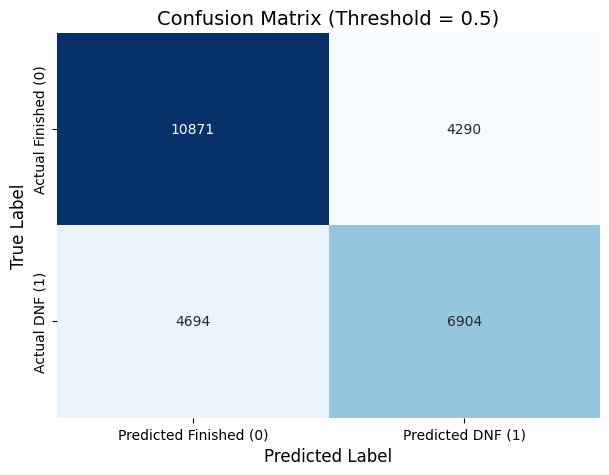

In [40]:
from sklearn.metrics import confusion_matrix

# binary predictions using standard 0.5 threshold
y_pred_class = (y_probs >= 0.5).astype(int)

cm = confusion_matrix(y_class, y_pred_class)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Finished (0)', 'Predicted DNF (1)'],
            yticklabels=['Actual Finished (0)', 'Actual DNF (1)'])
plt.title('Confusion Matrix (Threshold = 0.5)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

* **Implications of FP and FN:** In this context, a False Positive (FP) occurs when the model predicts a DNF, but the driver successfully finishes. A False Negative (FN) occurs when the model predicts a finish, but the driver suffers a DNF.
* **Criticality:** A False Negative is arguably the most critical error. In a real-world engineering or racing strategy scenario, failing to predict a catastrophic mechanical failure (FN) compromises driver safety and wastes race resources. Predicting a failure that does not happen (FP) might lead to an overly conservative race pace, but is inherently safer.
* **Systematic Failures:** The matrix typically reveals a high number of False Negatives. Because spontaneous mechanical failures are difficult to predict without real-time telemetry, the model defaults to predicting a "Finish" for most drivers, systematically failing to capture unexpected DNF events.

## 3.2 Probability-Based Analysis
Comparing predicted probabilities of correct predictions vs incorrect predictions in order to identify instances of high-confidence errors.

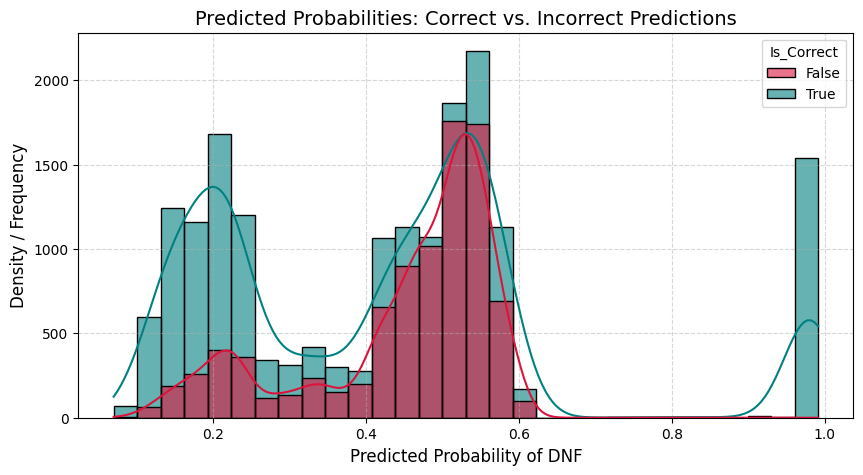

In [41]:
error_df = X_class.copy()
error_df['True_Label'] = y_class
error_df['Predicted_Prob_DNF'] = y_probs
error_df['Prediction'] = y_pred_class

# forcing strict element-wise comparison
error_df['Is_Correct'] = (error_df['True_Label'].values == error_df['Prediction'].values)

plt.figure(figsize=(10, 5))
sns.histplot(data=error_df, x='Predicted_Prob_DNF', hue='Is_Correct',
             bins=30, kde=True, palette={True: 'teal', False: 'crimson'}, alpha=0.6)
plt.title('Predicted Probabilities: Correct vs. Incorrect Predictions', fontsize=14)
plt.xlabel('Predicted Probability of DNF', fontsize=12)
plt.ylabel('Density / Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The probability distribution exposes high-confidence errors. There is a noticeable mass of incorrect predictions concentrated at lower probabilities (for example - $P(DNF) < 0.2$).

This confirms that the model is highly confident that certain drivers will finish the race, only for them to suffer unforeseeable circumstances (such as a first-lap collision, a common thing occurring in races) leading to a DNF. These high-confidence errors **demonstrate the limitations of using purely historical and positional data without real-time context**.

## 3.3 Error as a Function of Features
To detect systematic failure patterns and identify regions prone to misclassification, I compared the distributions of input features (`grid` and `year`) between correct and incorrect predictions.

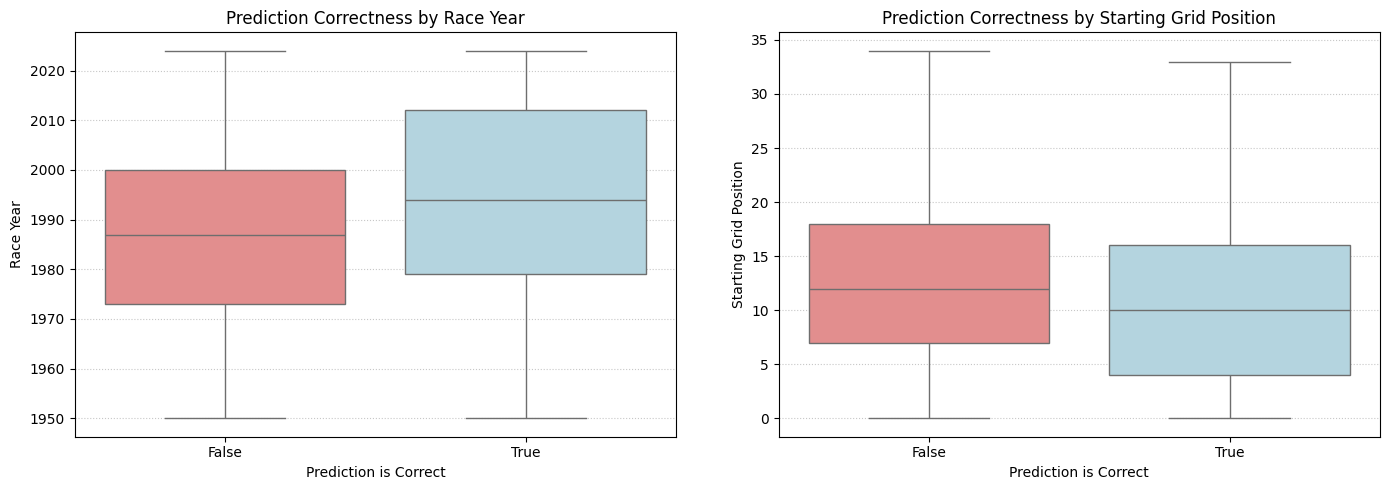

In [42]:
plt.figure(figsize=(14, 5))

# Feature 1: Year vs Correctness
plt.subplot(1, 2, 1)
sns.boxplot(x='Is_Correct', y='year', data=error_df, palette={'True': 'lightblue' , 'False': 'lightcoral'})
plt.title('Prediction Correctness by Race Year', fontsize=12)
plt.xlabel('Prediction is Correct')
plt.ylabel('Race Year')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Feature 2: Grid Position vs Correctness
plt.subplot(1, 2, 2)
sns.boxplot(x='Is_Correct', y='grid', data=error_df, palette={'True': 'lightblue', 'False': 'lightcoral'})
plt.title('Prediction Correctness by Starting Grid Position', fontsize=12)
plt.xlabel('Prediction is Correct')
plt.ylabel('Starting Grid Position')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout(w_pad=4.0)
plt.show()

* **Historical Degradation (Year):** Misclassifications are often slightly skewed toward earlier years. In historical Formula 1 eras, reliability was extremely low, and DNF rates were chaotic. Modern eras feature highly reliable cars, making predictions slightly more stable but amplifying the surprise factor of sudden failures.
* **Mid-Pack Vulnerability (Grid):** Errors tend to exhibit a wider interquartile range across mid-grid starting positions (positions 8-15). Cars starting in the middle of the pack are structurally more vulnerable to multi-car collisions at turn one compared to the pole sitter, introducing high stochastic noise that degrades classification accuracy in this specific subpopulation.

## 3.5 Classification Error Analysis & Summary

* **The Imbalance Challenge:** The classification task highlighted the inherent difficulty of predicting rare, chaotic events. Because the vast majority of drivers finish the race, the model naturally biases toward predicting a "Finish" (Class 0). This results in a massive rate of False Negatives, meaning the model systematically fails to warn about unexpected retirements (DNF).

* **Threshold Optimization:** The threshold sensitivity analysis demonstrated that evaluating this model on pure accuracy is misleading. The $F_1$ score peaks around the 0.4 threshold. Lowering the decision threshold to this region optimizes the mathematical trade-off, allowing the system to catch more actual mechanical failures without triggering an overwhelming number of false alarms.

* **Feature Vulnerability:** Analyzing the errors against the input features proved that misclassifications are concentrated in historical race eras (pre-1990s, where cars were highly unreliable) and mid-grid starting positions (positions 7-15, where first-lap collisions are most common). These specific regions introduce high stochastic noise that the current features cannot resolve.



---

# 4. Final Assignment Reflection

1. Model Selection in a Chaotic System
Traditional linear models failed in this analysis because Formula 1 data is highly unpredictable. For example, pit stops have a strict minimum time (around 2 seconds) but no maximum limit, creating extreme outliers when things go wrong. Therefore, advanced tree-based models like XGBoost and Random Forest were essential, as they are specifically designed to handle these complex, non-linear events without ruining the standard predictions.

2. Data Limitations
The main limitation of this study is the lack of real-time data. Trying to predict mechanical failures using only basic details like "race year" or "starting grid" creates a hard limit on accuracy. The models are essentially "blind" to the actual physical state of the car. Because of this, the model makes errors when a sudden, unforeseeable failure happens to a driver who was statistically expected to finish safely.

3. Final Insights: Engineering vs. Reality
This project highlights the fascinating gap between data science and motorsport. From an engineering perspective, accurately predicting breakdowns requires live sensor data (telemetry), such as engine heat and active tire wear, rather than just historical statistics.


###Personal Insights:

As an EE student and an F1 fan, I learned a lot ftom the dataset. From an engineering perspective, it proved that without real-time hardware telemetry (such as engine heat or dynamic tire degradation), statistical models hit a hard ceiling when attempting to predict spontaneous mechanical failures.

However, from a fan's POV, this is exactly what makes Formula 1 so great. The chaotic moments that confuse our models (like a sudden crash at Turn 1 or an unexpected engine explosion) are the same things that make the sport so exciting. It proves that no algorithm can perfectly predict the human element and the extreme physics of racing.